In [1]:
import numpy as np
from numpy.polynomial.legendre import Legendre

def generate_legendre_maps(
    X, M, m, coef_scale=1.0,
    perc_min=0.5, perc_max=99.5,
    clip=True, rng=None
):
    """
    Generate M random Legendre nonlinear projections based on 
    random linear directions in D-dimensional space.

    Parameters
    ----------
    X : array shape (N, D)
        Input data, used only to determine empirical domain bounds.
    M : int
        Number of independent nonlinear mappings to generate.
    m : int
        Legendre polynomial degree.
    coef_scale : float
        Std of the random normal Legendre coefficients.
    perc_min, perc_max : float
        Percentiles used to estimate the projection domain [a,b].
    clip : bool
        Whether to clip the input to the Legendre polynomial's domain.
    rng : np.random.Generator or None

    Returns
    -------
    mappings : list of functions
        Each f_i(x) computes P_i(u_i^T x).
    """
    if rng is None:
        rng = np.random.default_rng()

    X = np.asarray(X)
    N, D = X.shape

    mappings = []

    for _ in range(M):
        # Step 1: random projection direction
        u = rng.normal(size=D)
        u /= np.linalg.norm(u)

        # Step 2: project data along this direction
        z = X @ u

        # Step 3: compute stable percentile bounds
        a = np.percentile(z, perc_min)
        b = np.percentile(z, perc_max)

        # safety: ensure a < b
        if a == b:
            # fallback to small symmetric range
            a, b = -1.0, 1.0

        # Step 4: random Legendre coefficients
        coef = rng.normal(scale=coef_scale, size=m+1)

        # Step 5: build Legendre polynomial with domain mapping
        P = Legendre(coef, domain=[a, b], window=[-1, 1])

        # Step 6: build mapping function
        def make_map(u_local, P_local, a_local, b_local):
            def f(x):
                x = np.asarray(x)
                z = x @ u_local  # raw projection

                if clip:
                    z = np.clip(z, a_local, b_local)

                return P_local(z)
            return f

        mappings.append(make_map(u, P, a, b))

    # if only 1 mapping, return it directly
    if M == 1:
        return mappings[0]
    return mappings


In [9]:
N = 5000
D = 50
X = np.random.randn(N, D)

# generate 5 different degree-6 Legendre nonlinear projections
maps = generate_legendre_maps(X, M=1, m=3, coef_scale=0.5)

# evaluate the first mapping
y = maps(X)   # shape (5000,)

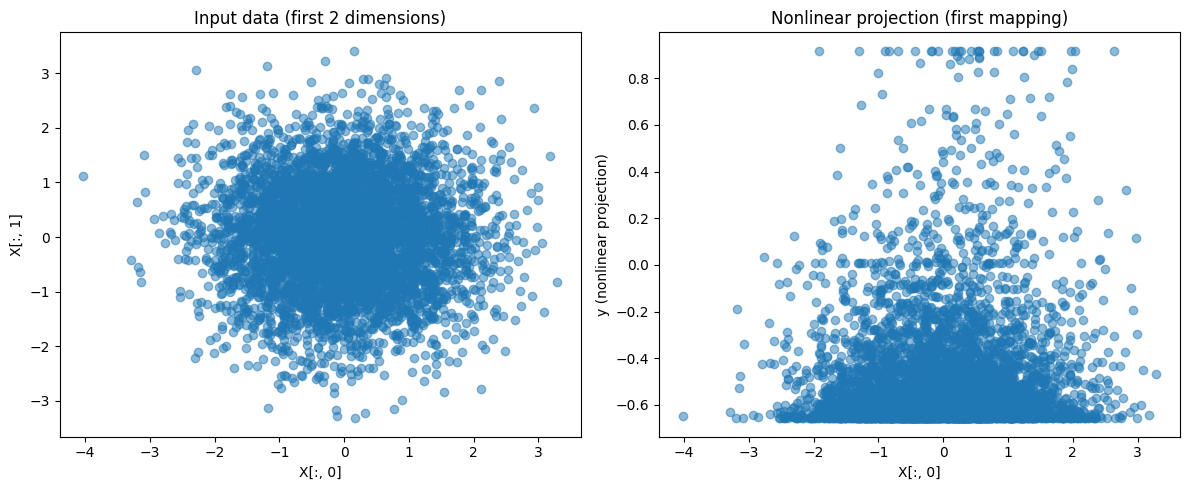

In [10]:
#plot the input data and one of the nonlinear projections
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Input data (first 2 dimensions)")
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.xlabel("X[:, 0]")
plt.ylabel("X[:, 1]")
plt.subplot(1, 2, 2)
plt.title("Nonlinear projection (first mapping)")
plt.scatter(X[:, 0], y, alpha=0.5)
plt.xlabel("X[:, 0]")
plt.ylabel("y (nonlinear projection)")
plt.tight_layout()
plt.show()